--------------------------------------Introduction to Machine Learning-----------------------------------------------

Group Name:  
    
Student # 1  
    Full Name: Alexis Perrin 
    Student Number/ID:  20231191
    Task : Step 1, 2, 3
Student # 2 
    Full Name:  Alex Brule
    Student Number/ID:  20230813
    Task : Step 4, 5
Student # 3 
    Full Name:  Laurent Qiu
    Student Number/ID:  20231188
    Task : Step 6, 7, 8


Step 1: Dataset Selection  

We selected the document House_data.csv

Step 2: Scenario/About Dataset: 

Scenario:
We are a real-estate company called LAA. Our goal is to help people sell their houses.

Problem definition:  
In order to sell houses at the best price, we want to build a machine learning model that can predict the selling price of a house using data such as its area, number of bedrooms, number of bathrooms.

Machine learning approach:  
We will train a supervised regression model that learns from past house data and predicts the price of new houses.  

Type of learning:  
Supervised Learning -> Regression

Reason:
By defining this problem clearly, we make sure our machine learning solution answers the real business need of LAA and improves the company’s daily work with clients.

In [18]:
#Step 3: Data Loading: 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We Load the dataset
df = pd.read_csv("House_data.csv")


# We display the first 5 rows of the dataframe
print("----------------------------- HEAD -----------------------------")
display(df.head())

----------------------------- HEAD -----------------------------


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3.0,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3.0,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2.0,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4.0,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3.0,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [19]:
# We show the information about the DataFrame
print("\n\n----------------------------- INFO -----------------------------")
df.info()



----------------------------- INFO -----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21600 non-null  float64
 4   bathrooms      21603 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-nu

In [20]:
# We show the summary statistics for numeric columns
print("\n\n----------------------------- DESCRIBE -----------------------------")
display(df.describe(include='all'))



----------------------------- DESCRIBE -----------------------------


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


Step 3 : 
The dataset contains 21,613 rows and 21 columns.  
Each row represents a single house sold, and each column describes one characteristic of the house.

This dataset gives detailed information about houses, which helps the model learn how size, quality, and location influence the price.

For the target we want to predict, we choose the column about the price.

Step 4: Data Wrangling or Data Pre-processing  

In this step, we prepared the dataset before using it for model training (as we did in the lab)

1. Checked for missing values and removed all rows that contained them.  
2. Checked for duplicate rows and removed them if found.  
3. Converted categorical variables (like date or location) into numeric columns.
4. Scaled all numerical features so that all values are on the same scale.  
5. Verified that there are no missing or non-numeric values left in the dataset.

After preprocessing, the dataset is clean, consistent, and ready for the next step.


In [21]:
# STEP 4 — Data Preprocessing

import pandas as pd
from sklearn.preprocessing import StandardScaler


In [22]:
# We check for missing values in each column
missing_values = df.isnull().sum()
display(missing_values)

# We remove rows with missing data
df.dropna(inplace=True)

id                0
date              0
price             0
bedrooms         13
bathrooms        10
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
grade             0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
zipcode           0
lat               0
long              0
sqft_living15     0
sqft_lot15        0
dtype: int64

In [23]:
df = pd.get_dummies(df, drop_first=True)

# We standardize numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# We display the first 5 rows of the preprocessed dataframe
display(df.head())


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,date_20150508T000000,date_20150509T000000,date_20150510T000000,date_20150511T000000,date_20150512T000000,date_20150513T000000,date_20150514T000000,date_20150515T000000,date_20150524T000000,date_20150527T000000
0,0.886034,-0.867015,-0.402903,-1.451073,-0.980652,-0.228182,-0.915552,-0.087205,-0.305715,-0.629986,...,False,False,False,False,False,False,False,False,False,False
1,0.637413,-0.006000,-0.402903,0.174486,0.533369,-0.189739,0.937431,-0.087205,-0.305715,-0.629986,...,False,False,False,False,False,False,False,False,False,False
2,0.365362,-0.981145,-1.482493,-1.451073,-1.427234,-0.123139,-0.915552,-0.087205,-0.305715,-0.629986,...,False,False,False,False,False,False,False,False,False,False
3,-0.727673,0.173775,0.676687,1.149821,-0.131057,-0.243878,-0.915552,-0.087205,-0.305715,2.444427,...,False,False,False,False,False,False,False,False,False,False
4,-0.912887,-0.082269,-0.402903,-0.150626,-0.436040,-0.169503,-0.915552,-0.087205,-0.305715,-0.629986,...,False,False,False,False,False,False,False,False,False,False


Insight after Step 4

We removed rows with missing data and transformed all features into a usable format for machine learning.  
The data is now clean and standardized, ready for training models.  
This step ensures that our future price predictions for LAA clients are based on reliable data.


Step 5: Exploratory Data Analysis: 

In [24]:
# STEP 5 — EDA
# We display basic statistical summary after preprocessing
display(df.describe())


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04,2.159700e+04
mean,5.000810e-17,-9.738420e-17,-1.750284e-16,1.368643e-16,-1.394963e-16,1.842404e-17,-5.264011e-17,-2.434605e-17,1.184402e-17,1.421283e-16,3.842728e-16,2.632005e-17,5.790412e-17,2.653061e-15,-2.632005e-17,-5.668879e-14,-1.784533e-14,-9.371255e-15,1.316003e-16,1.579203e-17
std,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00,1.000023e+00
min,-1.591936e+00,-1.258979e+00,-2.562083e+00,-2.101296e+00,-1.862923e+00,-3.520603e-01,-9.155523e-01,-8.720516e-02,-3.057155e-01,-3.704400e+00,-3.970359e+00,-1.713818e+00,-6.590309e-01,-2.417047e+00,-2.102096e-01,-1.438034e+00,-2.917338e+00,-2.167545e+00,-2.316968e+00,-4.439161e-01
25%,-8.542606e-01,-5.943556e-01,-4.029030e-01,-4.757376e-01,-7.083461e-01,-2.429124e-01,-9.155523e-01,-8.720516e-02,-3.057155e-01,-6.299864e-01,-5.608003e-01,-7.231696e-01,-6.590309e-01,-6.808504e-01,-2.102096e-01,-8.400356e-01,-6.423235e-01,-8.102422e-01,-7.247661e-01,-2.807926e-01
50%,-2.348354e-01,-2.457007e-01,-4.029030e-01,1.744858e-01,-1.855186e-01,-1.806594e-01,1.093927e-02,-8.720516e-02,-3.057155e-01,-6.299864e-01,-5.608003e-01,-2.761697e-01,-6.590309e-01,1.361833e-01,-2.102096e-01,-2.420370e-01,8.449749e-02,-1.209314e-01,-2.139772e-01,-1.883962e-01
75%,9.484672e-01,2.854532e-01,6.766871e-01,4.995975e-01,5.115847e-01,-1.065982e-01,9.374309e-01,-8.720516e-02,-3.057155e-01,9.072203e-01,2.915893e-01,5.091005e-01,6.060554e-01,8.851309e-01,-2.102096e-01,7.483981e-01,8.510157e-01,6.323360e-01,5.449091e-01,-9.808983e-02
max,1.849196e+00,1.950233e+01,3.198480e+01,7.652055e+00,1.248216e+01,3.951203e+01,3.716906e+00,1.146721e+01,4.913681e+00,2.444427e+00,4.553537e+00,9.207478e+00,1.022975e+01,1.497906e+00,4.804572e+00,2.262082e+00,1.569897e+00,6.388436e+00,6.163587e+00,3.147495e+01


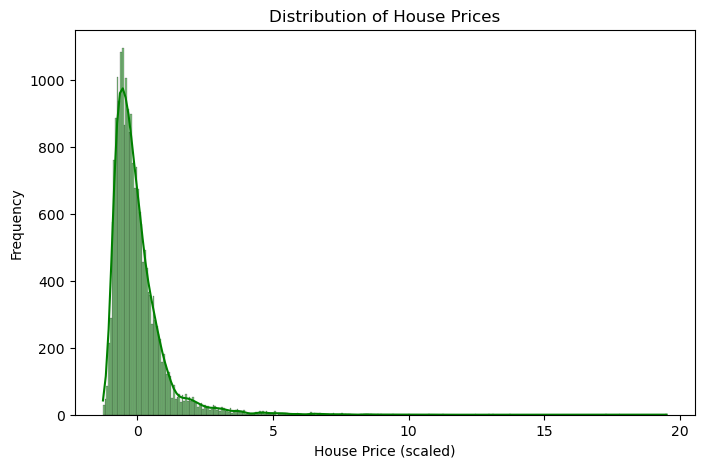

In [25]:
# We use plot for distribution of the target variable (house prices)
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='green')
plt.title('Distribution of House Prices')
plt.xlabel('House Price (scaled)')
plt.ylabel('Frequency')
plt.show()

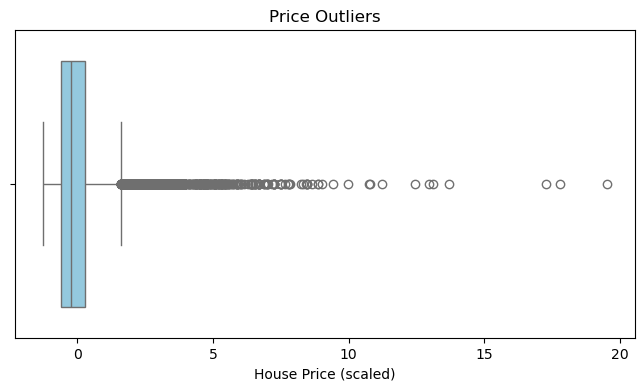

In [26]:
# We use boxplot to visualize outliers in the price variable
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Price Outliers')
plt.xlabel('House Price (scaled)')
plt.show()


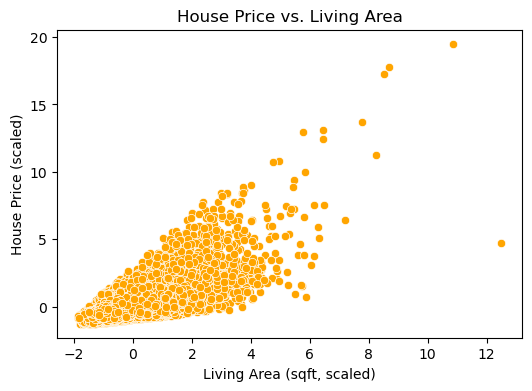

In [27]:
# We use scatter plot to examine relationship between sqft_living and price
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['sqft_living'], y=df['price'], color='orange')
plt.title('House Price vs. Living Area')
plt.xlabel('Living Area (sqft, scaled)')
plt.ylabel('House Price (scaled)')
plt.show()

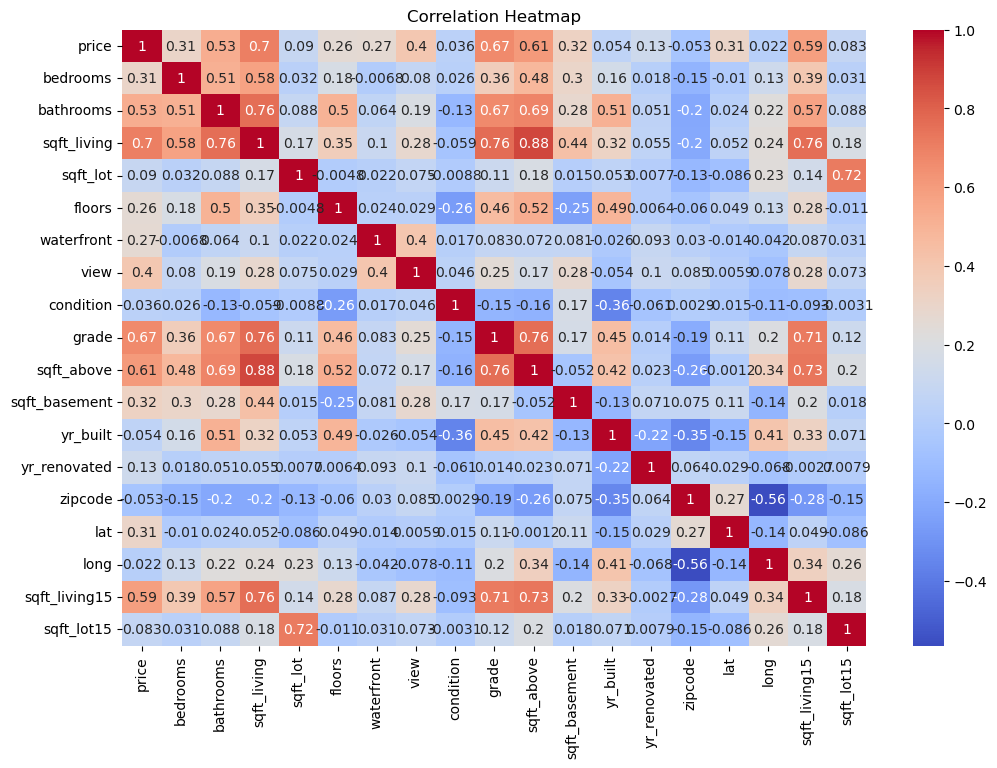

In [45]:
# We make a copy of the DataFrame to clean for correlation analysis
df_corr = df.copy()

# We drop the 'id' 
if 'id' in df_corr.columns:
    df_corr.drop(columns=['id'], inplace=True)

# We drop all columns that came from date
date_cols = [col for col in df_corr.columns if 'date' in col]
df_corr.drop(columns=date_cols, inplace=True)

# Plot a clean correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.title('Correlation Heatmap')
plt.show()


Insight after Step 5

We observed that the price distribution is strongly altered, with a few houses being very expensive.  
Features like sqft_living, bathrooms, and grade have a strong impact on the price.  
Now the company LAA knowing which house attributes increase the value and can be highlighted to clients.


In [31]:
# STEP 6 — MODEL DEVELOPMENT 
from sklearn.model_selection import train_test_split

# We separate features (X) and target variable (y)
X = df.drop('price', axis=1)
y = df['price']

# we split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


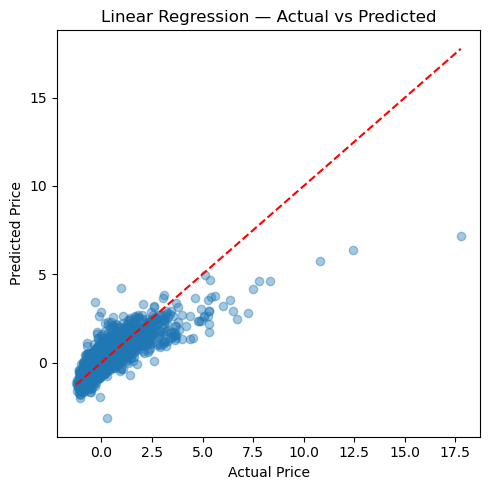

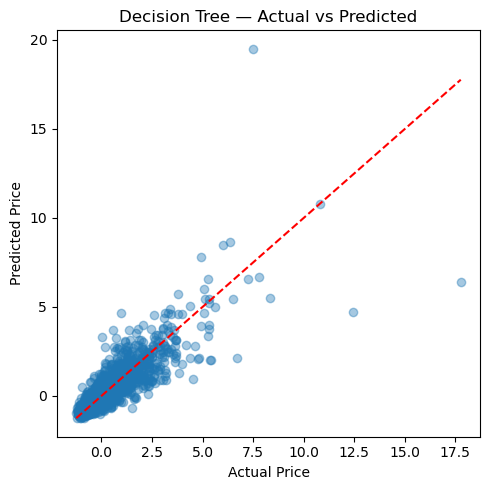

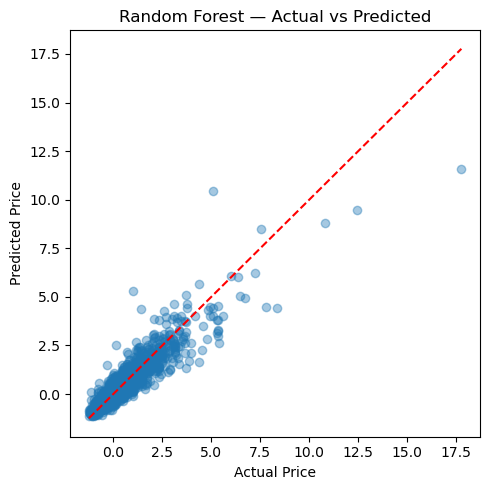

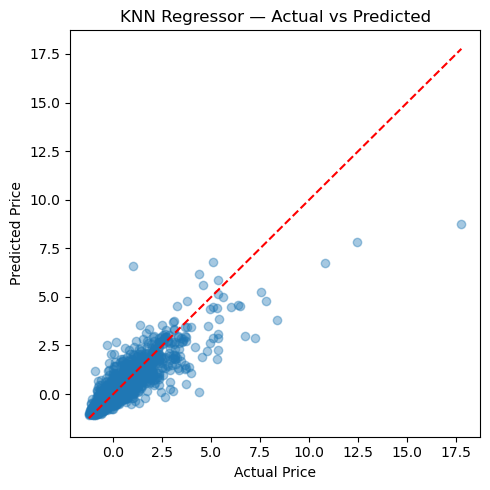

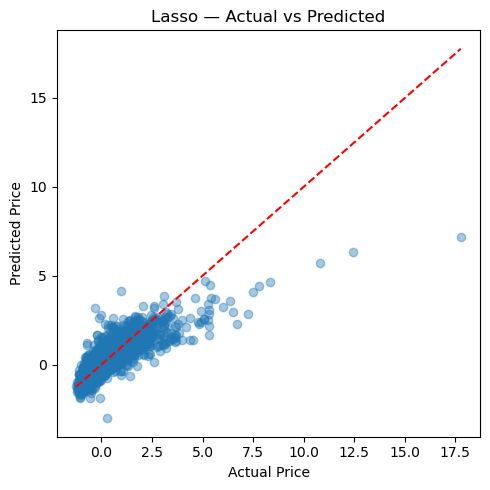

In [33]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# We initialize models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
knn = KNeighborsRegressor(n_neighbors=5)
lasso = Lasso(alpha=0.001, max_iter=10000, random_state=42)

# We train all models on the training set
for model in [lr, dt, rf, knn, lasso]:
    model.fit(X_train, y_train)

# SCHEMA BY MODELE : REEL PRICE VS PREDICTED 

import matplotlib.pyplot as plt

# We know evaluate models on test data and collect the results
models = {
    "Linear Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN Regressor": knn,
    "Lasso": lasso
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure(figsize=(5,5))
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')  # ligne idéale
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{name} — Actual vs Predicted")
    plt.tight_layout()
    plt.show()

Insight after Step 6

We trained 5 models to predict house prices.  
These include simple and advanced methods, so LAA can choose the best balance between speed and accuracy.  
The models are now ready to be tested and compared.


In [34]:
# STEP 7 — MODEL EVALUATION (ajout des bonus)

from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd


results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred)
    })

# We create a dataframe of results and sort by R2 score
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
display(results_df)


,Model,R2,MSE
2,Random Forest,0.874451,0.121183
3,KNN Regressor,0.782132,0.210292
1,Decision Tree,0.733749,0.256993
4,Lasso,0.691193,0.298069
0,Linear Regression,0.689436,0.299765


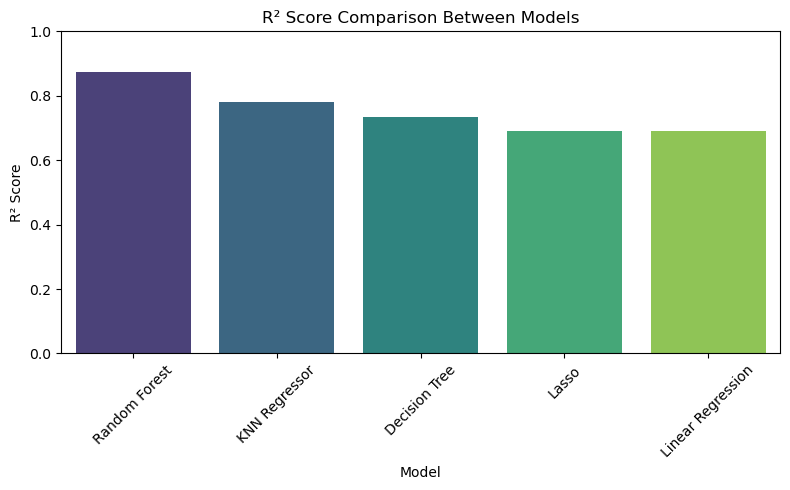

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x=results_df["Model"], y=results_df["R2"], hue=results_df["Model"], palette="viridis", legend=False)
plt.ylim(0, 1)
plt.title("R² Score Comparison Between Models")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Insight after Step 7

We realise that Random Forest Regressor gave the best results, with the highest R2 score.  
This means it can predict house prices more accurately than the other models.  
LAA can use this model to give realistic and fast price estimates to future sellers.


Step 8 — Conclusion and Business Impact
  
Our goal was to help the company estimate house prices more accurately and more quickly for clients who want to sell their homes.

We used a real housing dataset and applied a full machine learning pipeline:
- We cleaned the data and removed missing values
- We explored the most important features
- We trained 5 models, including bonus models (Lasso and KNN Regressor)

Best model:  
The Random Forest Regressor gave the best results with the highest R2 and lowest MSE.

Business value:
This model can now be used to give LAA agents a quick and objective price estimation.  
It improves the negotiation process and helps sellers make better decisions.

Next steps:  
To improve the model even more, we could:
- Add more detailed location data or renovation info
- Tune the model hyperparameters
- Update the dataset regularly with new sales

This project shows how machine learning can give direct value to a company and improve its work with real clients.
